# Fig. 5 Reproduction — Character-Level Attention Maps

Reproduces a character-level attention grid similar to Fig. 5 from *"Beyond Memorization:*
*Extracting the Trained Knowledge in Deep Neural Networks"* (Springer LNCS 14627).

**Layout**: Single row — Input image + one heatmap per decoded character.  
**Method**: Gradient saliency |∂logit(c,t)/∂x| — backprop from the CTC peak logit
of each character to the input pixels. This is the most scientifically sound approach
for a CTC-based model because it directly measures each input pixel's contribution
to each character prediction.

**Image**: `"talks."` (6 characters), tightly cropped to text bounding box.

In [1]:
# Cell 1 — Imports & config
import sys, json, os
from pathlib import Path
from types import SimpleNamespace
import numpy as np
import torch
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter

ROOT = Path('.').resolve()
if ROOT.name == 'notebook':
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from models import HTRNet
from utils.preprocessing import load_image, preprocess

DEVICE = 'cpu'
IMG_H, IMG_W = 128, 1024
EXP = ROOT / 'saved_models' / 'experiments'
OUT = ROOT / 'outputs' / 'attention_maps'
OUT.mkdir(parents=True, exist_ok=True)

charset = list(np.load(str(EXP / 'classes.npy'), allow_pickle=True))
print(f'Charset: {len(charset)} classes, ROOT: {ROOT}')

Charset: 79 classes, ROOT: /home/hpc/iwi5/iwi5369h/HTR-Pipeline


In [2]:
# Cell 2 — Load model & image
RUN = 'run_63'  # 8 register tokens, CER 6.26%
IMG_FILE = 'a01-038-12.png'  # GT: "talks."

# Load model
cfg = json.load(open(EXP / RUN / 'config.json'))
model = HTRNet(SimpleNamespace(**cfg['arch']), len(charset) + 1)
model.load_state_dict(
    torch.load(str(EXP / RUN / 'model.pt'), map_location=DEVICE, weights_only=False),
    strict=False
)
model = model.to(DEVICE).eval()
R = model.backbone.num_registers
print(f'Model: {RUN}, registers: {R}')

# Load & preprocess image
raw = load_image(str(ROOT / 'notebook' / 'sample_images' / IMG_FILE))
img = preprocess(raw, (IMG_H, IMG_W))  # [128, 1024], inverted: 0=white, high=ink
tensor = torch.from_numpy(img).unsqueeze(0).unsqueeze(0).float().to(DEVICE)
print(f'Image: {img.shape}, range [{img.min():.3f}, {img.max():.3f}]')

/home/hpc/iwi5/iwi5369h/HTR-Pipeline/.venv/lib/python3.12/site-packages/torch/nn/modules/transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


Model: run_63, registers: 8
Image: (128, 1024), range [0.004, 0.843]


In [3]:
# Cell 3 — CTC decode: get characters and their temporal positions
with torch.no_grad():
    logits = model(tensor)  # [T, B, C]

probs = torch.softmax(logits[:, 0, :], dim=-1)  # [T, C]
ids = probs.argmax(dim=-1).cpu().numpy()

chars, peaks = [], []
prev = -1
for t, idx in enumerate(ids):
    if idx != 0 and idx != prev:  # skip blank (0) and repeats
        ci = idx - 1
        if 0 <= ci < len(charset):
            chars.append(charset[ci])
            peaks.append(t)
    prev = idx

decoded = ''.join(chars)
print(f'Decoded: "{decoded}"')
print(f'Characters: {list(zip(chars, peaks))}')

Decoded: " talks. "
Characters: [(np.str_(' '), 0), (np.str_('t'), 3), (np.str_('a'), 6), (np.str_('l'), 9), (np.str_('k'), 12), (np.str_('s'), 16), (np.str_('.'), 20), (np.str_(' '), 127)]


Crop: [0:128, 4:172] → (128, 168)
Removed 84% blank space


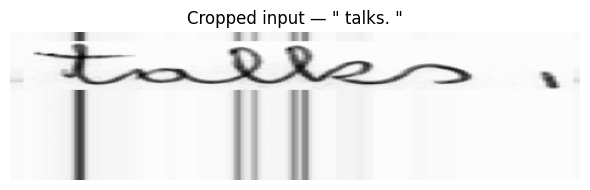

In [4]:
# Cell 4 — Tight crop to text bounding box
#
# Images are INVERTED: 0 = white background, high = ink.
# So ink columns/rows have HIGH mean values.

def tight_crop(img, pad=8):
    """Crop to ink bounding box. img is inverted (0=white, high=ink)."""
    col_mean = img.mean(axis=0)  # [W]
    row_mean = img.mean(axis=1)  # [H]
    ct = col_mean.max() * 0.05
    rt = row_mean.max() * 0.05
    cc = np.where(col_mean > ct)[0]
    rr = np.where(row_mean > rt)[0]
    if len(cc) == 0 or len(rr) == 0:
        return img, (0, img.shape[0], 0, img.shape[1])
    x0, x1 = max(0, cc[0] - pad), min(img.shape[1], cc[-1] + pad)
    y0, y1 = max(0, rr[0] - pad), min(img.shape[0], rr[-1] + pad)
    return img[y0:y1, x0:x1], (y0, y1, x0, x1)

img_crop, (y0, y1, x0, x1) = tight_crop(img)
print(f'Crop: [{y0}:{y1}, {x0}:{x1}] → {img_crop.shape}')
print(f'Removed {100*(1 - img_crop.size/img.size):.0f}% blank space')

fig, ax = plt.subplots(1, 1, figsize=(6, 2))
ax.imshow(img_crop, cmap='gray_r', aspect='auto')
ax.set_title(f'Cropped input — "{decoded}"', fontsize=12)
ax.axis('off')
plt.tight_layout()
plt.show()

In [5]:
# Cell 5 — Compute gradient saliency for each character
#
# For character c decoded at CTC time-step t:
#   saliency(c) = |∂ logit[t, class(c)] / ∂ x|
# This measures how much each input pixel influences that character's prediction.

saliency_maps = []

for i, (ch, t) in enumerate(zip(chars, peaks)):
    inp = tensor.clone().detach().requires_grad_(True)
    model.zero_grad()
    logits = model(inp)  # [T, B, C]
    class_idx = charset.index(ch) + 1  # +1 because class 0 = CTC blank
    logits[t, 0, class_idx].backward()
    
    grad = inp.grad[0, 0].abs().cpu().numpy()  # [H, W]
    grad = gaussian_filter(grad, sigma=2)       # smooth
    grad_crop = grad[y0:y1, x0:x1]              # crop to text box
    
    # Normalize to [0, 1]
    gmin, gmax = grad_crop.min(), grad_crop.max()
    if gmax > gmin:
        grad_crop = (grad_crop - gmin) / (gmax - gmin)
    
    saliency_maps.append(grad_crop)
    print(f'  [{i}] "{ch}" @ t={t}, class={class_idx}')

print(f'\nComputed {len(saliency_maps)} saliency maps.')

  [0] " " @ t=0, class=1
  [1] "t" @ t=3, class=73
  [2] "a" @ t=6, class=54
  [3] "l" @ t=9, class=65
  [4] "k" @ t=12, class=64
  [5] "s" @ t=16, class=72
  [6] "." @ t=20, class=13
  [7] " " @ t=127, class=1

Computed 8 saliency maps.


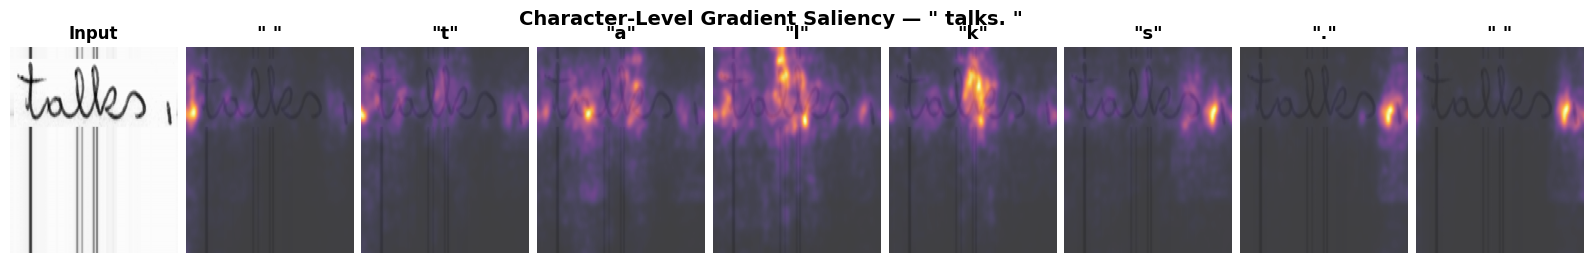

Saved: /home/hpc/iwi5/iwi5369h/HTR-Pipeline/outputs/attention_maps/fig5_saliency.png


In [6]:
# Cell 6 — Plot: Fig. 5 style character attention grid
#
# Layout: [Input] [char1] [char2] ... [charN]
# All cells show the same cropped region.
# Saliency is overlaid as a heatmap on the faded input image.

n = len(chars)
ncols = n + 1  # input + characters
aspect = img_crop.shape[0] / img_crop.shape[1]
cell_w = 2.2
cell_h = cell_w * aspect
cell_h = max(cell_h, 1.0)

fig, axes = plt.subplots(1, ncols, figsize=(cell_w * ncols + 0.5, cell_h + 1.0))

# Input image
axes[0].imshow(img_crop, cmap='gray_r', aspect='auto')
axes[0].set_title('Input', fontsize=12, fontweight='bold', pad=6)
axes[0].axis('off')

# Character saliency maps
for i, (ch, sal) in enumerate(zip(chars, saliency_maps)):
    ax = axes[i + 1]
    ax.imshow(img_crop, cmap='gray_r', aspect='auto', alpha=0.25)
    im = ax.imshow(sal, cmap='inferno', aspect='auto', alpha=0.75, vmin=0, vmax=1)
    ax.set_title(f'"{ch}"', fontsize=13, fontweight='bold', pad=6)
    ax.axis('off')

fig.suptitle(
    f'Character-Level Gradient Saliency — "{decoded}"',
    fontsize=14, fontweight='bold', y=1.02
)
plt.subplots_adjust(wspace=0.05)

fig.savefig(str(OUT / 'fig5_saliency.png'), dpi=200, bbox_inches='tight')
fig.savefig(str(OUT / 'fig5_saliency.pdf'), bbox_inches='tight')
plt.show()
print(f'Saved: {OUT / "fig5_saliency.png"}')

Attention shape: (136, 136), R=8, Wp=128


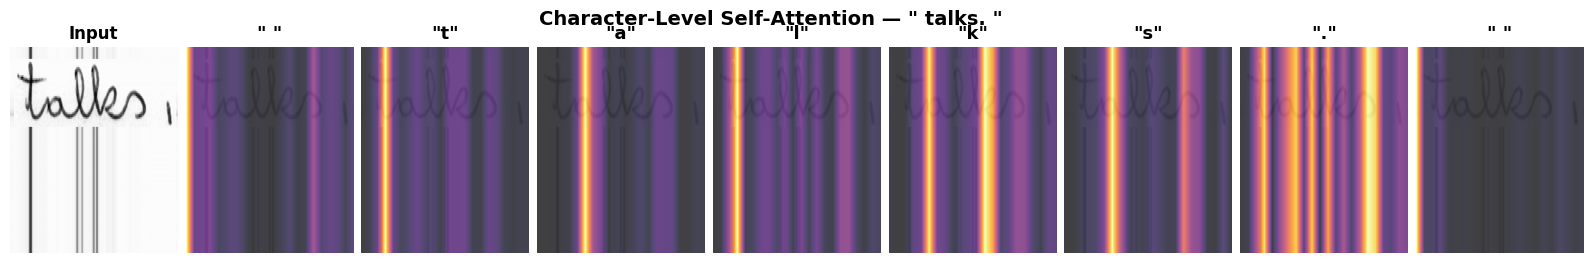

Saved: /home/hpc/iwi5/iwi5369h/HTR-Pipeline/outputs/attention_maps/fig5_self_attn.png


In [7]:
# Cell 7 — Alternative: Self-Attention map per character
#
# Extract the attention row for each character's CTC peak token
# from the last transformer layer. This shows where the model
# "looks" in the input sequence when predicting each character.

with torch.no_grad():
    seq_out, reg_out, attn_maps, norms, (Hp, Wp) = model.forward_explain(tensor)

# Last layer attention, average over heads: [S, S]
attn_last = attn_maps[-1][0].mean(dim=0).numpy()  # [S, S]
print(f'Attention shape: {attn_last.shape}, R={R}, Wp={Wp}')

# Crop in patch space
scale = IMG_W / Wp  # pixels per patch
p_left = max(0, int(x0 / scale))
p_right = min(Wp, int(np.ceil(x1 / scale)))

attn_char_maps = []
for i, (ch, t) in enumerate(zip(chars, peaks)):
    qi = R + t  # query index in full sequence (skip register tokens)
    row = attn_last[qi, R:]  # attention to patch tokens only [Wp]
    row_crop = row[p_left:p_right]
    # Normalize
    rmin, rmax = row_crop.min(), row_crop.max()
    if rmax > rmin:
        row_crop = (row_crop - rmin) / (rmax - rmin)
    attn_char_maps.append(row_crop)

# Plot
fig, axes = plt.subplots(1, ncols, figsize=(cell_w * ncols + 0.5, cell_h + 1.0))

axes[0].imshow(img_crop, cmap='gray_r', aspect='auto')
axes[0].set_title('Input', fontsize=12, fontweight='bold', pad=6)
axes[0].axis('off')

for i, (ch, a1d) in enumerate(zip(chars, attn_char_maps)):
    ax = axes[i + 1]
    # Broadcast 1D attention to 2D (height-uniform since patches are 1D)
    from scipy.ndimage import zoom as spzoom
    a_up = spzoom(a1d, img_crop.shape[1] / len(a1d), order=1)[:img_crop.shape[1]]
    a_2d = np.tile(a_up, (img_crop.shape[0], 1))
    
    ax.imshow(img_crop, cmap='gray_r', aspect='auto', alpha=0.25)
    ax.imshow(a_2d, cmap='inferno', aspect='auto', alpha=0.75, vmin=0, vmax=1)
    ax.set_title(f'"{ch}"', fontsize=13, fontweight='bold', pad=6)
    ax.axis('off')

fig.suptitle(
    f'Character-Level Self-Attention — "{decoded}"',
    fontsize=14, fontweight='bold', y=1.02
)
plt.subplots_adjust(wspace=0.05)

fig.savefig(str(OUT / 'fig5_self_attn.png'), dpi=200, bbox_inches='tight')
fig.savefig(str(OUT / 'fig5_self_attn.pdf'), bbox_inches='tight')
plt.show()
print(f'Saved: {OUT / "fig5_self_attn.png"}')

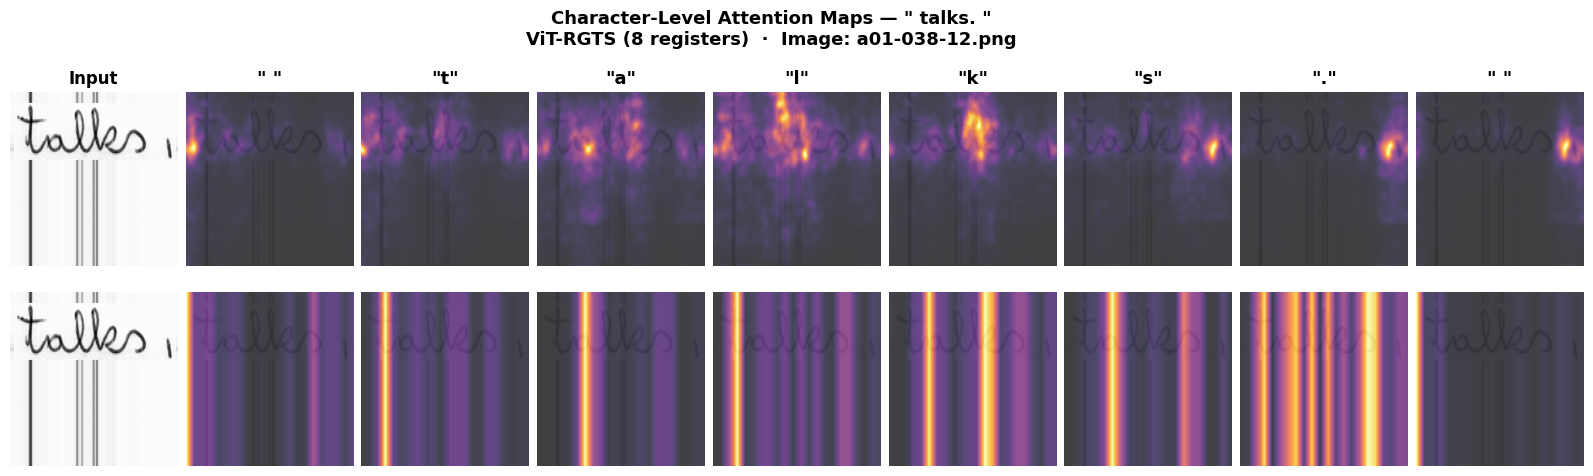

Saved: /home/hpc/iwi5/iwi5369h/HTR-Pipeline/outputs/attention_maps/fig5_combined.png


In [8]:
# Cell 8 — Combined figure: both methods side by side
#
# Row 1: Gradient saliency (2D — pixel-level)
# Row 2: Self-attention (1D → broadcast)

fig, axes = plt.subplots(2, ncols, figsize=(cell_w * ncols + 0.5, 2 * cell_h + 1.5))

for row, (maps, label) in enumerate([
    (saliency_maps, 'Gradient Saliency'),
    (attn_char_maps, 'Self-Attention')
]):
    # Input column
    axes[row, 0].imshow(img_crop, cmap='gray_r', aspect='auto')
    axes[row, 0].set_ylabel(label, fontsize=11, fontweight='bold', labelpad=8)
    axes[row, 0].axis('off')
    if row == 0:
        axes[row, 0].set_title('Input', fontsize=12, fontweight='bold', pad=6)
    
    for i, (ch, m) in enumerate(zip(chars, maps)):
        ax = axes[row, i + 1]
        ax.imshow(img_crop, cmap='gray_r', aspect='auto', alpha=0.25)
        
        if row == 1:  # self-attention: broadcast 1D → 2D
            from scipy.ndimage import zoom as spzoom
            a_up = spzoom(m, img_crop.shape[1] / len(m), order=1)[:img_crop.shape[1]]
            heatmap = np.tile(a_up, (img_crop.shape[0], 1))
        else:
            heatmap = m
        
        ax.imshow(heatmap, cmap='inferno', aspect='auto', alpha=0.75, vmin=0, vmax=1)
        ax.axis('off')
        if row == 0:
            ax.set_title(f'"{ch}"', fontsize=13, fontweight='bold', pad=6)

fig.suptitle(
    f'Character-Level Attention Maps — "{decoded}"\n'
    f'ViT-RGTS ({R} registers)  ·  Image: {IMG_FILE}',
    fontsize=13, fontweight='bold', y=1.05
)
plt.subplots_adjust(wspace=0.05, hspace=0.15)

fig.savefig(str(OUT / 'fig5_combined.png'), dpi=200, bbox_inches='tight')
fig.savefig(str(OUT / 'fig5_combined.pdf'), bbox_inches='tight')
plt.show()
print(f'Saved: {OUT / "fig5_combined.png"}')